In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cell 2: load dataset from a public raw CSV
# This dataset has video game sales data including GTA titles.
csv_url = "https://gist.githubusercontent.com/designernatan/27da044c6dc823f7ac7fe3a01f4513ed/raw/d15b5c7d7a5efb38750b16ec935fc126ec9a6e79/vgsales.csv"

df = pd.read_csv(csv_url)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
# Cell 3: look at how many games, missing values, etc.
print("Total rows:", len(df))
print(df.info())
print(df.isnull().sum())

Total rows: 16598
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB
None
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [4]:
# Cell 4: basic stats on Global_Sales
df["Global_Sales"].describe()

count    16598.000000
mean         0.537441
std          1.555028
min          0.010000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.740000
Name: Global_Sales, dtype: float64

In [5]:
# Cell 5: binary target using median split
threshold = df["Global_Sales"].median()
print("Median global sales:", threshold)

df["High_Sales"] = (df["Global_Sales"] >= threshold).astype(int)
df["High_Sales"].value_counts()

Median global sales: 0.17


High_Sales
1    8461
0    8137
Name: count, dtype: int64

In [6]:
# Cell 6: fill/clean minimal
# Drop rows with missing Year or Global_Sales if any, or fill them.
df = df.dropna(subset=["Year", "Global_Sales", "Name", "Genre"])
df["Year"] = df["Year"].astype(int)

In [7]:
# Cell 7: combine Name + Genre for text features
df["text_feat"] = df["Name"].str.lower() + " " + df["Genre"].str.lower()

In [8]:
# Cell 8: define features and target
numeric_features = ["Year", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
text_feature = "text_feat"
target = "High_Sales"

In [9]:
# Cell 9: split data
X_train, X_test, y_train, y_test = train_test_split(
    df[[*numeric_features, text_feature]],
    df[target],
    test_size=0.2,
    random_state=42,
    stratify=df[target]
)

print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 13061 Test size: 3266


In [10]:
# Cell 10: create a simple transformer for numeric features
from sklearn.base import BaseEstimator, TransformerMixin

class NumericSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.columns].values

class TextSelector(BaseEstimator, TransformerMixin):
    def __init__(self, column):
        self.column = column
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.column].values.astype(str)

In [11]:
# Cell 11: combine numeric and text in a FeatureUnion style
from sklearn.pipeline import FeatureUnion

numeric_pipeline = Pipeline([
    ("selector", NumericSelector(numeric_features)),
    ("scaler", StandardScaler())
])

text_pipeline = Pipeline([
    ("selector", TextSelector(text_feature)),
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),      # unigrams + bigrams
        max_features=2000,      # limit features for speed
        stop_words="english"
    ))
])

full_pipeline = FeatureUnion(transformer_list=[
    ("num", numeric_pipeline),
    ("text", text_pipeline)
])

model_pipeline = Pipeline([
    ("features", full_pipeline),
    ("clf", LogisticRegression(
        solver="liblinear",   # good for small-medium datasets and binary
        max_iter=1000,
        random_state=42
    ))
])

In [12]:
# Cell 12: fit model
model_pipeline.fit(X_train, y_train)

# Cell 13: predictions
y_pred = model_pipeline.predict(X_test)

# Cell 14: metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9770361298224127


NameError: name 'precision_score' is not defined

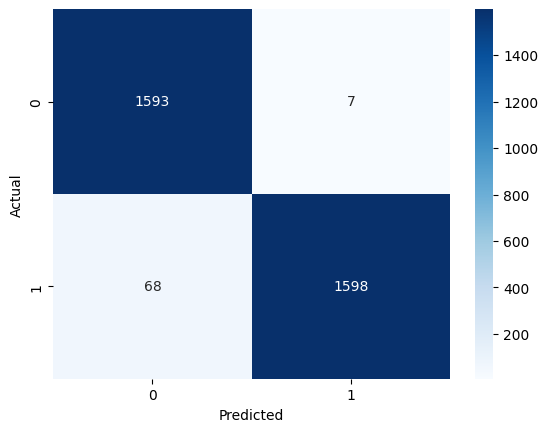

In [13]:
# Cell 15: confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
# Cell 16: get feature names
num_feats = numeric_features
text_feats = model_pipeline.named_steps["features"].transformer_list[1][1] \
    .named_steps["tfidf"].get_feature_names_out()

all_feats = np.concatenate([num_feats, text_feats])

# coefficients
coefs = model_pipeline.named_steps["clf"].coef_.flatten()

# show top positive and negative
coef_df = pd.DataFrame({"feature": all_feats, "coef": coefs})
top_pos = coef_df.sort_values(by="coef", ascending=False).head(20)
top_neg = coef_df.sort_values(by="coef", ascending=True).head(20)

print("Top positive features:")
print(top_pos)
print("\nTop negative features:")
print(top_neg)

Top positive features:
          feature       coef
1        NA_Sales  23.844942
2        EU_Sales  15.337549
3        JP_Sales   9.481522
4     Other_Sales   9.017879
149        aliens   1.040733
385    conspiracy   0.929973
278         bratz   0.908881
1951    wolverine   0.845283
17             09   0.840279
179    armageddon   0.821620
1659        spyro   0.812277
160       america   0.809939
135    adventures   0.795534
14      07 sports   0.786413
1048      magical   0.772519
669       friends   0.741054
1150        movie   0.724187
1283        party   0.720490
205          ball   0.718967
2004          zoo   0.708936

Top negative features:
        feature      coef
1633       soul -0.774907
1336   portable -0.762071
1156      music -0.686032
1347      power -0.683785
460       derby -0.618784
1272       pack -0.606541
1620     soccer -0.569456
819     history -0.562343
626       field -0.561858
1064      mania -0.553142
1453        rio -0.539181
1709        sun -0.537554
128   

In [15]:
# Cell 17: filter GTA entries
gta_df = df[df["Name"].str.contains("Grand Theft Auto", case=False, na=False)]
gta_df[["Name", "Platform", "Year", "Global_Sales", "High_Sales"]]

,Name,Platform,Year,Global_Sales,High_Sales
16,Grand Theft Auto V,PS3,2013,21.40,1
17,Grand Theft Auto: San Andreas,PS2,2004,20.81,1
23,Grand Theft Auto V,X360,2013,16.38,1
24,Grand Theft Auto: Vice City,PS2,2002,16.15,1
38,Grand Theft Auto III,PS2,2001,13.10,1
44,Grand Theft Auto V,PS4,2014,11.98,1
51,Grand Theft Auto IV,X360,2008,11.02,1
56,Grand Theft Auto IV,PS3,2008,10.57,1
90,Grand Theft Auto: Liberty City Stories,PSP,2005,7.72,1
197,Grand Theft Auto V,XOne,2014,5.08,1


In [16]:
# Cell 18: predictions for GTA
X_gta = gta_df[[*numeric_features, text_feature]]
gta_preds = model_pipeline.predict(X_gta)
gta_df["Predicted_High_Sales"] = gta_preds
gta_df[["Name", "Platform", "Year", "Global_Sales", "High_Sales", "Predicted_High_Sales"]]

,Name,Platform,Year,Global_Sales,High_Sales,Predicted_High_Sales
16,Grand Theft Auto V,PS3,2013,21.40,1,1
17,Grand Theft Auto: San Andreas,PS2,2004,20.81,1,1
23,Grand Theft Auto V,X360,2013,16.38,1,1
24,Grand Theft Auto: Vice City,PS2,2002,16.15,1,1
38,Grand Theft Auto III,PS2,2001,13.10,1,1
44,Grand Theft Auto V,PS4,2014,11.98,1,1
51,Grand Theft Auto IV,X360,2008,11.02,1,1
56,Grand Theft Auto IV,PS3,2008,10.57,1,1
90,Grand Theft Auto: Liberty City Stories,PSP,2005,7.72,1,1
197,Grand Theft Auto V,XOne,2014,5.08,1,1
